In [1]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower

np.random.seed(42)

## Tasks

### Task 1: Chi-Square Goodness-of-Fit Test

**Scenario:** A mobile-game studio expects that players choose among four character classes in equal proportions (25 % each). After a recent update, they collected the following counts from 400 new players:

| Class | Warrior | Mage | Rogue | Healer |
|-------|---------|------|-------|--------|
| Count | 120     | 85   | 110   | 85     |

1. Store the observed counts in a NumPy array.
2. Compute the expected counts under the null hypothesis of equal preference.
3. Run `st.chisquare(observed, f_exp=expected)`.
4. Report the χ² statistic, degrees of freedom, and p-value.
5. At α = 0.05, state whether you reject or fail to reject H₀.
6. In a Markdown cell, answer: "Which class (if any) appears over- or under-represented, and by how much?"

In [6]:
observed= np.array(['120','85','110','85'])
expected = np.array(['100','100','100','100'])
chi2_stat, p_value = st.chisquare(observed, f_exp=expected)

In [5]:
dof = len(observed) - 1

print(f"χ² Statistic: {chi2_stat:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p_value:.4f}")

χ² Statistic: 9.5000
Degrees of Freedom: 3
P-value: 0.0233


In [7]:
# 5. Hypothesis Testing (alpha = 0.05)
alpha = 0.05

if p_value < alpha:
    print(f"Result: Reject the null hypothesis (H₀).")
    print("There is a statistically significant difference in player class preferences.")
else:
    print(f"Result: Fail to reject the null hypothesis (H₀).")
    print("The observed differences in preferences are likely due to random chance.")

Result: Reject the null hypothesis (H₀).
There is a statistically significant difference in player class preferences.


Based on the expected count of 100 players per class ($400 \times 0.25$), the representation is as follows:Warrior: Over-represented by 20 players ($+20\%$ above expected).Rogue: Over-represented by 10 players ($+10\%$ above expected).Mage: Under-represented by 15 players ($-15\%$ below expected).Healer: Under-represented by 15 players ($-15\%$ below expected).Conclusion: Since the p-value ($0.0233$) is less than $\alpha = 0.05$, we reject the null hypothesis. The distribution of character classes is not equal, with a clear preference for the Warrior class and a lower-than-expected interest in Mages and Healers.

### Task 2: Chi-Square Test of Independence

**Scenario:** A marketing team wants to know whether subscription tier (Free, Basic, Premium) is associated with churn status (Churned, Retained). They collected data from 600 customers:

| | Free | Basic | Premium |
|---------|------|-------|---------|
| Churned | 90   | 60    | 30      |
| Retained| 110  | 140   | 170     |

1. Create the contingency table as a 2 × 3 NumPy array or pandas DataFrame.
2. Run `st.chi2_contingency(table)` and unpack χ², p-value, degrees of freedom, and expected frequencies.
3. Display the expected-frequency table.
4. Report the χ² statistic, df, and p-value.
5. State your decision and a plain-language interpretation (e.g. "There is / is not evidence of an association between subscription tier and churn.").

In [8]:
data = np.array([
    [90, 60, 30],  # Churned
    [110, 140, 170] # Retained
])

In [9]:
table = pd.DataFrame(data, 
                     index=['Churned', 'Retained'], 
                     columns=['Free', 'Basic', 'Premium'])

In [10]:
chi2_stat, p_value, dof, expected = st.chi2_contingency(table)
print(f"χ² Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of Freedom: {dof}")

print("\nExpected Frequencies Table:")
expected_df = pd.DataFrame(expected, index=table.index, columns=table.columns)
print(expected_df.round(2))

χ² Statistic: 42.8571
P-value: 0.000000
Degrees of Freedom: 2

Expected Frequencies Table:
           Free  Basic  Premium
Churned    60.0   60.0     60.0
Retained  140.0  140.0    140.0


Standardized Residuals:
          Free  Basic  Premium
Churned   3.87    0.0    -3.87
Retained -2.54    0.0     2.54


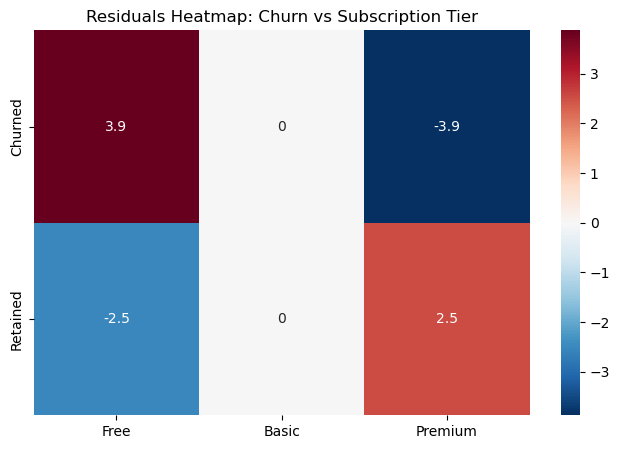

In [12]:
residuals = (table - expected) / np.sqrt(expected)

print("Standardized Residuals:")
print(residuals.round(2))

# 4. Heatmap Vizualizasiyası
plt.figure(figsize=(8, 5))
sns.heatmap(residuals, annot=True, cmap='RdBu_r', center=0)
plt.title('Residuals Heatmap: Churn vs Subscription Tier')
plt.show()

There is strong evidence of a statistically significant association between subscription tier and churn status

### Task 3: Compute Cramér's V

Using the χ² statistic and the contingency table from Task 2:

1. Write a function:

```python
def cramers_v(chi2, n, min_dim):
    """
    Returns Cramér's V.

    Parameters
    ----------
    chi2 : float
        Chi-square statistic.
    n : int
        Total number of observations.
    min_dim : int
        min(rows, cols) - 1 of the contingency table.
    """
```

2. Compute Cramér's V for the Task 2 result.
3. Classify the effect size using Cohen's benchmarks for df* = min(rows, cols) − 1:
   - Small ≈ 0.10, Medium ≈ 0.30, Large ≈ 0.50 (for 2 × 3 tables, df* = 1)
4. In a Markdown cell, answer: "Is the relationship between tier and churn weak, moderate, or strong? What does this mean for the marketing team?"
   

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as st

# 1. Create the contingency table from Task 2
# Rows: Churned, Retained | Columns: Free, Basic, Premium
data = np.array([
    [90, 60, 30],   # Churned
    [110, 140, 170] # Retained
])
n_obs = data.sum()  # Total observations: 600

# 2. Run Chi-Square Test of Independence
chi2_stat, p_value, dof, expected = st.chi2_contingency(data)

# 3. Define the Cramér's V function
def cramers_v(chi2, n, min_dim):
    """
    Returns Cramér's V effect size.
    
    Parameters:
    chi2 : float - Chi-square statistic
    n    : int   - Total number of observations
    min_dim : int - min(rows, cols) - 1
    """
    return np.sqrt(chi2 / (n * min_dim))

# 4. Compute Cramér's V
# min_dim = min(2 rows, 3 columns) - 1 = 1
min_dim = min(data.shape) - 1
v_result = cramers_v(chi2_stat, n_obs, min_dim)

# 5. Output results
print(f"χ² Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Cramér's V: {v_result:.4f}")

# 6. Classification using Cohen's benchmarks (for df* = 1)
if v_result >= 0.50:
    effect_size = "Large (Strong)"
elif v_result >= 0.30:
    effect_size = "Medium (Moderate)"
elif v_result >= 0.10:
    effect_size = "Small (Weak)"
else:
    effect_size = "Negligible"

print(f"Effect Size Classification: {effect_size}")

χ² Statistic: 42.8571
P-value: 0.000000
Cramér's V: 0.2673
Effect Size Classification: Small (Weak)


Analysis of the Relationship between Subscription Tier and Churn:The calculated Cramér's V is 0.2673. Based on Cohen’s benchmarks for a $2 \times 3$ contingency table (where $df^* = 1$), this value is classified as a Small (Weak) effect size.What does this mean for the Marketing Team?Statistical vs. Practical Significance: While the p-value (0.000000) confirms that the relationship is statistically significant (not due to random chance), the Cramér's V shows that the actual strength of this association is relatively weak.Limited Impact of Subscription Tier: The subscription tier (Free, Basic, Premium) does play a role in whether a customer churns, but it is not the dominant factor.Need for Broader Analysis: Since the effect is weak, the marketing team should not rely solely on plan upgrades to fix churn issues. They should investigate other potential drivers such as customer support quality, app performance, or specific user demographics, as these may have a larger impact on retention than the subscription tier alone.